# MSD Artist Clustering Analysis

This notebook performs comprehensive artist-level clustering and popularity analysis on the extracted Million Song Dataset features.

## Objectives:
1. Load and explore the extracted CSV files
2. Perform exploratory data analysis (EDA)
3. Implement K-Means and Gaussian Mixture Model (GMM) clustering
4. Analyze cluster-popularity relationships using ANOVA and t-tests
5. Generate visualizations and interpretable insights

**Author:** Data Analysis Team  
**Date:** January 2026  
**Dataset:** Million Song Dataset (10k subset)

## Section 1: Setup & Data Loading

Import necessary libraries, configure settings, and load the extracted CSV files.

In [1]:
# Import data manipulation and analysis libraries
import pandas as pd
import numpy as np
import warnings

# Import machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Import statistical analysis libraries
from scipy.stats import f_oneway, ttest_ind

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully")
print(f"  - pandas: {pd.__version__}")
print(f"  - numpy: {np.__version__}")

✓ All libraries imported successfully
  - pandas: 2.3.3
  - numpy: 2.1.3


In [2]:
# Load the extracted CSV files
print("Loading data...")

songs_df = pd.read_csv('output/songs_10k_features.csv')
artists_df = pd.read_csv('output/artists_1500_features.csv')
segments_df = pd.read_csv('output/segments_long.csv', nrows=1000)  # Sample for memory efficiency
beats_df = pd.read_csv('output/beats_long.csv', nrows=1000)  # Sample for memory efficiency

print(f"\n✓ Data loaded successfully")
print(f"  - Songs shape: {songs_df.shape}")
print(f"  - Artists shape: {artists_df.shape}")
print(f"  - Segments shape: {segments_df.shape} (sample)")
print(f"  - Beats shape: {beats_df.shape} (sample)")
print(f"\n  Focus: Artist-level clustering using {len(artists_df)} artists")

Loading data...

✓ Data loaded successfully
  - Songs shape: (10000, 82)
  - Artists shape: (3888, 151)
  - Segments shape: (1000, 34) (sample)
  - Beats shape: (1000, 7) (sample)

  Focus: Artist-level clustering using 3888 artists

✓ Data loaded successfully
  - Songs shape: (10000, 82)
  - Artists shape: (3888, 151)
  - Segments shape: (1000, 34) (sample)
  - Beats shape: (1000, 7) (sample)

  Focus: Artist-level clustering using 3888 artists


## Section 2: Data Exploration & Cleaning

Understand the data structure, identify issues, and prepare for clustering analysis.

In [3]:
# 1. Missing value analysis
print("=== Missing Value Analysis ===\n")

missing_counts = artists_df.isnull().sum()
missing_percentages = (missing_counts / len(artists_df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts[missing_counts > 0],
    'Missing %': missing_percentages[missing_percentages > 0]
}).sort_values('Missing %', ascending=False)

print(f"Columns with missing values: {len(missing_df)}/{len(artists_df.columns)}")
print(f"\nTop 10 columns with most missing values:")
print(missing_df.head(10))

# Identify zero-variance columns
zero_var_cols = [col for col in artists_df.select_dtypes(include=[np.number]).columns
                 if artists_df[col].std() == 0]
print(f"\n✓ Zero-variance columns: {len(zero_var_cols)}")
if zero_var_cols:
    print(f"  {zero_var_cols[:5]}{'...' if len(zero_var_cols) > 5 else ''}")

=== Missing Value Analysis ===

Columns with missing values: 74/151

Top 10 columns with most missing values:
                                      Missing Count  Missing %
artist_duration_std                            1561  40.149177
artist_analysis_sample_rate_std                1561  40.149177
artist_key_std                                 1561  40.149177
artist_tempo_std                               1561  40.149177
artist_time_signature_std                      1561  40.149177
artist_time_signature_confidence_std           1561  40.149177
artist_mode_std                                1561  40.149177
artist_key_confidence_std                      1561  40.149177
artist_mode_confidence_std                     1561  40.149177
artist_loudness_std                            1561  40.149177

✓ Zero-variance columns: 6
  ['artist_analysis_sample_rate_mean', 'artist_analysis_sample_rate_std', 'artist_danceability_mean', 'artist_danceability_std', 'artist_energy_mean']...


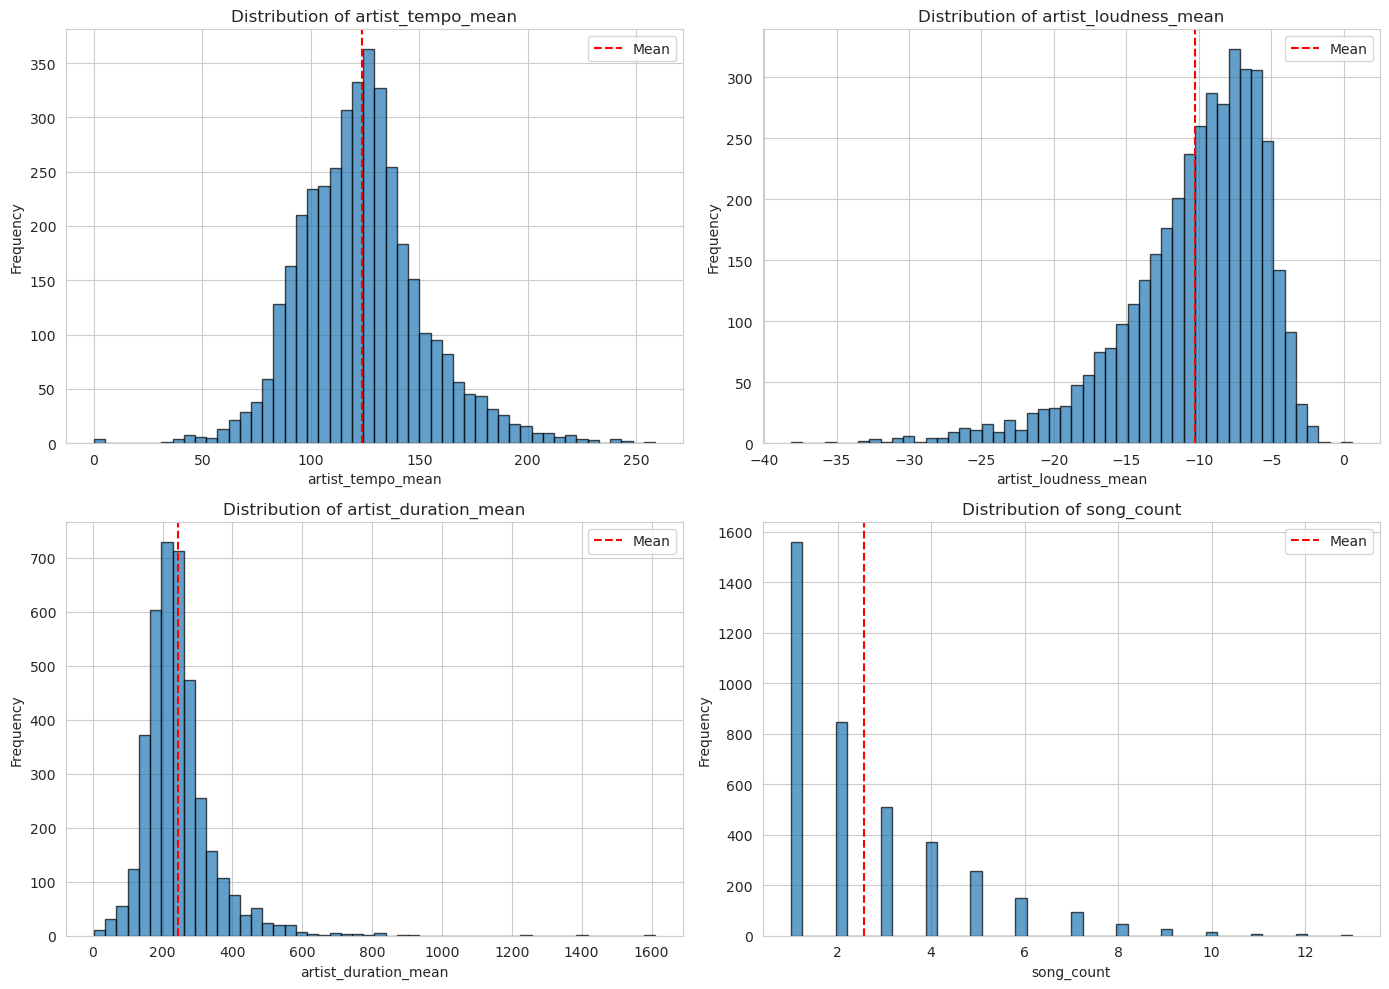


=== Summary Statistics ===
       artist_tempo_mean  artist_loudness_mean  artist_duration_mean  \
count        3888.000000           3888.000000           3888.000000   
mean          123.395208            -10.258741            243.462114   
std            28.255492              4.849836             99.775087   
min             0.000000            -38.148000              3.552200   
25%           104.718528            -12.642437            185.582287   
50%           122.096000             -9.267167            229.054241   
75%           137.951500             -6.794250            277.126080   
max           258.677000              0.566000           1610.004440   

        song_count  
count  3888.000000  
mean      2.572016  
std       1.924871  
min       1.000000  
25%       1.000000  
50%       2.000000  
75%       3.000000  
max      13.000000  


In [4]:
# 2. Distribution overview for key features
key_features = ['artist_tempo_mean', 'artist_loudness_mean', 'artist_duration_mean', 'song_count']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    if feature in artists_df.columns:
        axes[idx].hist(artists_df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {feature}')
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel('Frequency')
        axes[idx].axvline(artists_df[feature].mean(), color='r', linestyle='--', label='Mean')
        axes[idx].legend()

plt.tight_layout()
plt.show()

print("\n=== Summary Statistics ===")
print(artists_df[key_features].describe())

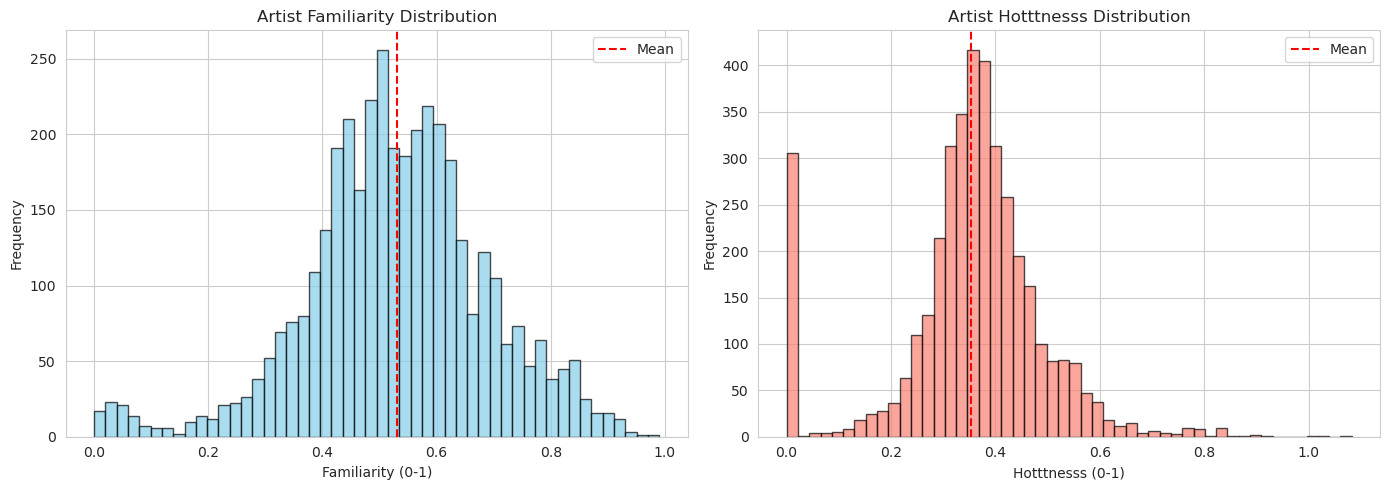


=== Popularity Correlation ===
                         artist_familiarity_mean  artist_hotttnesss_mean
artist_familiarity_mean                 1.000000                0.793965
artist_hotttnesss_mean                  0.793965                1.000000


In [5]:
# 3. Popularity distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(artists_df['artist_familiarity_mean'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Artist Familiarity Distribution')
axes[0].set_xlabel('Familiarity (0-1)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(artists_df['artist_familiarity_mean'].mean(), color='r', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(artists_df['artist_hotttnesss_mean'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='salmon')
axes[1].set_title('Artist Hotttnesss Distribution')
axes[1].set_xlabel('Hotttnesss (0-1)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(artists_df['artist_hotttnesss_mean'].mean(), color='r', linestyle='--', label='Mean')
axes[1].legend()

plt.tight_layout()
plt.show()

# Correlation between familiarity and hotttnesss
corr = artists_df[['artist_familiarity_mean', 'artist_hotttnesss_mean']].corr()
print("\n=== Popularity Correlation ===")
print(corr)

In [6]:
# 4. Handle missing data
print("=== Handling Missing Data ===\n")

# Make a copy for processing
artists_clean = artists_df.copy()

# For columns with <10% missing: impute with median
impute_cols = missing_df[missing_df['Missing %'] < 10].index.tolist()
for col in impute_cols:
    if col in artists_clean.columns:
        median_val = artists_clean[col].median()
        artists_clean[col].fillna(median_val, inplace=True)

print(f"✓ Imputed {len(impute_cols)} columns with median values")

# For columns with >50% missing: drop (if any)
drop_cols = missing_df[missing_df['Missing %'] > 50].index.tolist()
if drop_cols:
    artists_clean.drop(columns=drop_cols, inplace=True)
    print(f"✓ Dropped {len(drop_cols)} columns with >50% missing")

# Drop zero-variance columns
if zero_var_cols:
    artists_clean.drop(columns=zero_var_cols, inplace=True, errors='ignore')
    print(f"✓ Dropped {len(zero_var_cols)} zero-variance columns")

print(f"\nFinal shape: {artists_clean.shape}")
print(f"Remaining missing values: {artists_clean.isnull().sum().sum()}")

=== Handling Missing Data ===

✓ Imputed 1 columns with median values
✓ Dropped 6 zero-variance columns

Final shape: (3888, 145)
Remaining missing values: 109270


## Section 3: Feature Selection & Preprocessing

Select appropriate features for clustering, standardize them, and apply dimensionality reduction.

In [7]:
# 1. Feature selection for clustering
print("=== Feature Selection ===\n")

# Exclude non-clustering columns
exclude_cols = [
    'artist_id', 'artist_name', 'song_count',  # Identifiers
    'artist_familiarity_mean', 'artist_hotttnesss_mean',  # Evaluation only
]

# Select numeric columns, excluding those we don't want
numeric_cols = artists_clean.select_dtypes(include=[np.number]).columns.tolist()
clustering_features = [col for col in numeric_cols if col not in exclude_cols]

# Remove any columns with 'danceability' or 'energy' (often zeros in MSD)
clustering_features = [col for col in clustering_features
                       if 'danceability' not in col.lower() and 'energy' not in col.lower()]

print(f"✓ Selected {len(clustering_features)} features for clustering")
print(f"\nFeature categories:")
print(f"  - Tempo features: {len([c for c in clustering_features if 'tempo' in c])}")
print(f"  - Loudness features: {len([c for c in clustering_features if 'loudness' in c])}")
print(f"  - Timbre features: {len([c for c in clustering_features if 'timbre' in c])}")
print(f"  - Pitch features: {len([c for c in clustering_features if 'pitch' in c])}")

# Extract feature matrix
X = artists_clean[clustering_features].copy()

# Fill any remaining NaN with 0 (should be minimal after cleaning)
X = X.fillna(0)

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"  Remaining NaN values: {X.isnull().sum().sum()}")

=== Feature Selection ===

✓ Selected 140 features for clustering

Feature categories:
  - Tempo features: 2
  - Loudness features: 14
  - Timbre features: 48
  - Pitch features: 48

✓ Feature matrix shape: (3888, 140)
  Remaining NaN values: 0


In [8]:
# 2. Standardization
print("=== Feature Standardization ===\n")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print(f"✓ Features standardized")
print(f"  Mean: {X_scaled.mean().mean():.2e}")
print(f"  Std: {X_scaled.std().mean():.3f}")
print(f"\nOriginal feature ranges (first 5 features):")
print(X.iloc[:, :5].describe().loc[['min', 'max']])
print(f"\nScaled feature ranges (first 5 features):")
print(X_scaled.iloc[:, :5].describe().loc[['min', 'max']])

=== Feature Standardization ===

✓ Features standardized
  Mean: -2.80e-17
  Std: 1.000

Original feature ranges (first 5 features):
     artist_duration_mean  artist_duration_std  artist_tempo_mean  \
min               3.55220             0.000000              0.000   
max            1610.00444           836.012791            258.677   

     artist_tempo_std  artist_time_signature_mean  
min          0.000000                         1.0  
max        118.821516                         7.0  

Scaled feature ranges (first 5 features):
     artist_duration_mean  artist_duration_std  artist_tempo_mean  \
min             -2.404816            -0.613839          -4.367685   
max             13.697990            13.047115           4.788421   

     artist_tempo_std  artist_time_signature_mean  
min         -0.865100                   -2.604967  
max          5.236658                    3.452988  


=== PCA Dimensionality Reduction ===

✓ PCA analysis complete
  Components for 85% variance: 46 (85.11%)
  Components for 90% variance: 61 (90.17%)
  Total original features: 140


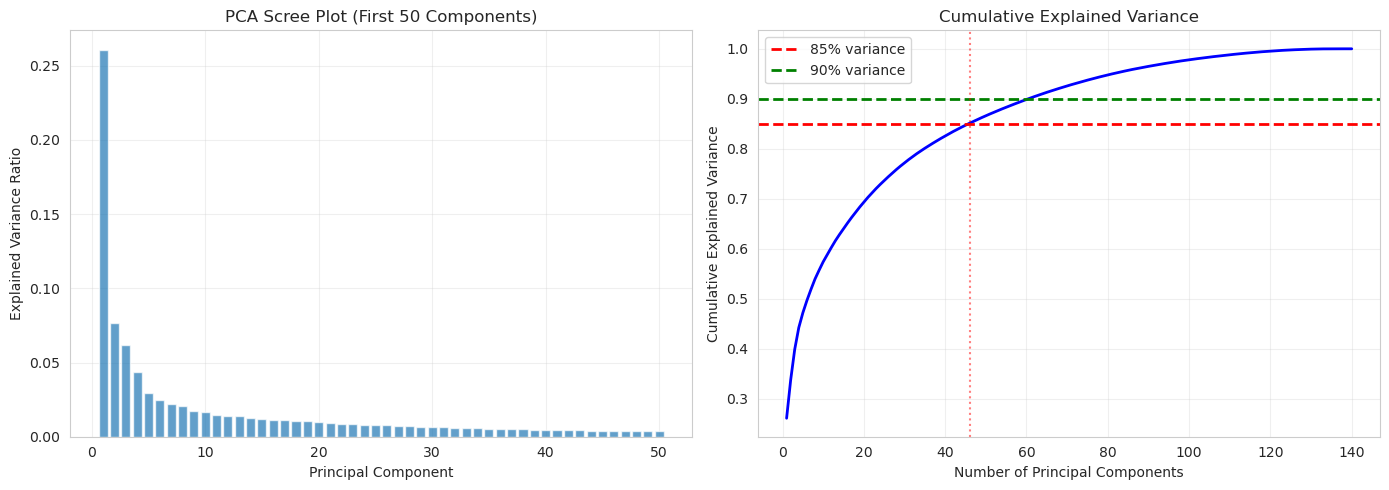


✓ Reduced feature space: (3888, 46)


In [9]:
# 3. Dimensionality reduction with PCA
print("=== PCA Dimensionality Reduction ===\n")

# Apply PCA to find optimal components
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative explained variance
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_85 = np.argmax(cumsum >= 0.85) + 1
n_components_90 = np.argmax(cumsum >= 0.90) + 1

print(f"✓ PCA analysis complete")
print(f"  Components for 85% variance: {n_components_85} ({cumsum[n_components_85-1]:.2%})")
print(f"  Components for 90% variance: {n_components_90} ({cumsum[n_components_90-1]:.2%})")
print(f"  Total original features: {X_scaled.shape[1]}")

# Plot scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
ax1.bar(range(1, min(51, len(pca.explained_variance_ratio_)+1)),
        pca.explained_variance_ratio_[:50], alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('PCA Scree Plot (First 50 Components)')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, len(cumsum)+1), cumsum, 'b-', linewidth=2)
ax2.axhline(0.85, color='r', linestyle='--', label='85% variance', linewidth=2)
ax2.axhline(0.90, color='g', linestyle='--', label='90% variance', linewidth=2)
ax2.axvline(n_components_85, color='r', linestyle=':', alpha=0.5)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Use 85% threshold for clustering
pca_optimal = PCA(n_components=n_components_85)
X_pca_reduced = pca_optimal.fit_transform(X_scaled)

print(f"\n✓ Reduced feature space: {X_pca_reduced.shape}")

## Section 4: K-Means Clustering

Apply K-Means clustering with optimal number of clusters determined by elbow method and silhouette analysis.

=== Testing K-Means for k = 4, 5, 6, 7 ===

k=4:
  Inertia: 311115.53
  Silhouette: 0.093
  Davies-Bouldin: 2.982

k=4:
  Inertia: 311115.53
  Silhouette: 0.093
  Davies-Bouldin: 2.982

k=5:
  Inertia: 300657.73
  Silhouette: 0.079
  Davies-Bouldin: 2.835

k=5:
  Inertia: 300657.73
  Silhouette: 0.079
  Davies-Bouldin: 2.835

k=6:
  Inertia: 292097.94
  Silhouette: 0.077
  Davies-Bouldin: 2.741

k=6:
  Inertia: 292097.94
  Silhouette: 0.077
  Davies-Bouldin: 2.741

k=7:
  Inertia: 284038.45
  Silhouette: 0.077
  Davies-Bouldin: 2.598

=== Summary Table ===
 k       Inertia  Silhouette  Davies-Bouldin
 4 311115.534677    0.093108        2.981675
 5 300657.728416    0.078589        2.835184
 6 292097.942043    0.077303        2.740969
 7 284038.454447    0.077003        2.598384

✓ Best k based on highest Silhouette score: 4
  Silhouette: 0.093
  Davies-Bouldin: 2.982
k=7:
  Inertia: 284038.45
  Silhouette: 0.077
  Davies-Bouldin: 2.598

=== Summary Table ===
 k       Inertia  Silhouette

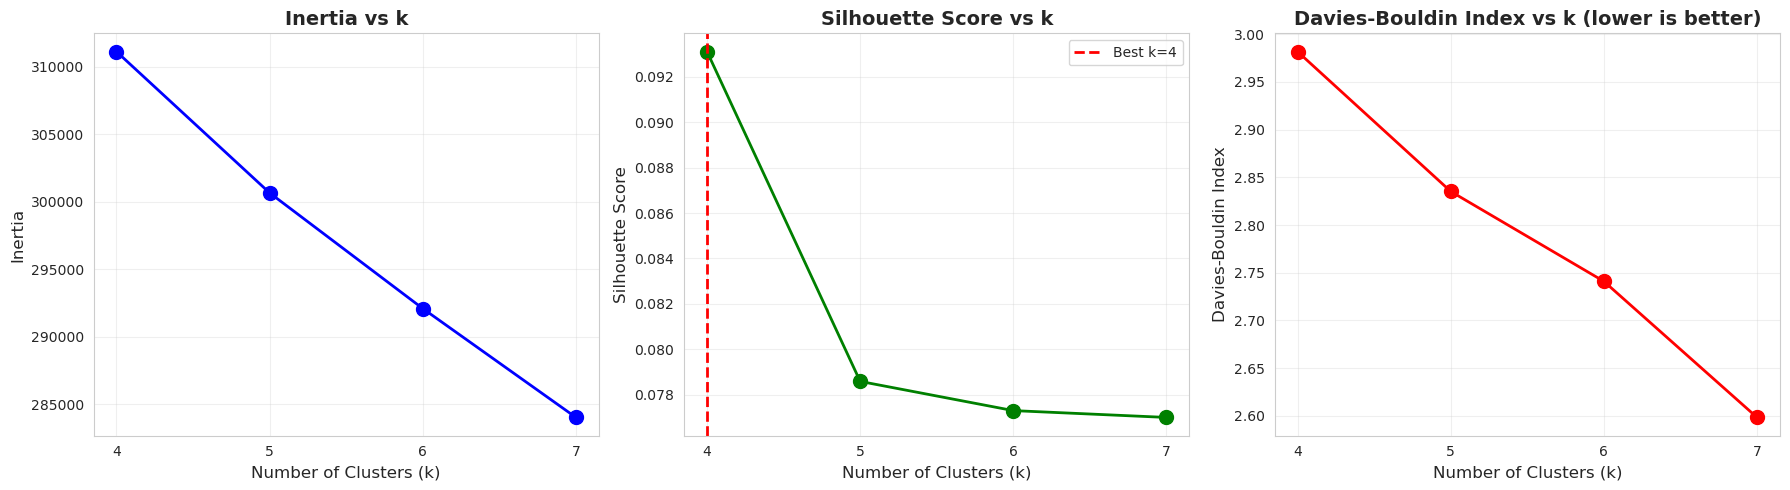

In [21]:
# 1. Test specific k values for K-Means: 4, 5, 6, 7
print("=== Testing K-Means for k = 4, 5, 6, 7 ===\n")

test_k_values = [4, 5, 6, 7]
k_results = []

for k in test_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_reduced)
    sil_score = silhouette_score(X_pca_reduced, labels)
    db_score = davies_bouldin_score(X_pca_reduced, labels)

    k_results.append({
        'k': k,
        'Inertia': kmeans.inertia_,
        'Silhouette': sil_score,
        'Davies-Bouldin': db_score
    })
    print(f"k={k}:")
    print(f"  Inertia: {kmeans.inertia_:.2f}")
    print(f"  Silhouette: {sil_score:.3f}")
    print(f"  Davies-Bouldin: {db_score:.3f}")
    print()

# Create results dataframe
k_results_df = pd.DataFrame(k_results)
print("=== Summary Table ===")
print(k_results_df.to_string(index=False))

# Choose best k based on silhouette score
best_k_idx = k_results_df['Silhouette'].idxmax()
optimal_k = k_results_df.loc[best_k_idx, 'k']

print(f"\n✓ Best k based on highest Silhouette score: {optimal_k}")
print(f"  Silhouette: {k_results_df.loc[best_k_idx, 'Silhouette']:.3f}")
print(f"  Davies-Bouldin: {k_results_df.loc[best_k_idx, 'Davies-Bouldin']:.3f}")

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_results_df['k'], k_results_df['Inertia'], 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Inertia vs k', fontsize=14, fontweight='bold')
axes[0].set_xticks(test_k_values)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_results_df['k'], k_results_df['Silhouette'], 'go-', linewidth=2, markersize=10)
axes[1].axvline(optimal_k, color='r', linestyle='--', linewidth=2, label=f'Best k={optimal_k}')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs k', fontsize=14, fontweight='bold')
axes[1].set_xticks(test_k_values)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_results_df['k'], k_results_df['Davies-Bouldin'], 'ro-', linewidth=2, markersize=10)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[2].set_title('Davies-Bouldin Index vs k (lower is better)', fontsize=14, fontweight='bold')
axes[2].set_xticks(test_k_values)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== Training Final K-Means Model ===

✓ K-Means clustering complete with k=4

Cluster sizes:
kmeans_cluster
0     809
1    1375
2     919
3     785
Name: count, dtype: int64


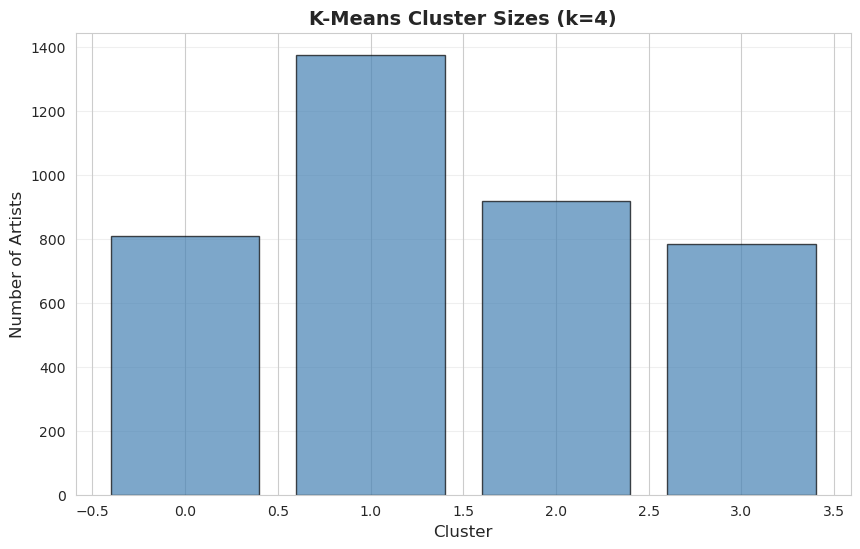

In [22]:
# 2. Train final K-Means model
print("=== Training Final K-Means Model ===\n")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
artists_clean['kmeans_cluster'] = kmeans_final.fit_predict(X_pca_reduced)

print(f"✓ K-Means clustering complete with k={optimal_k}")
print(f"\nCluster sizes:")
print(artists_clean['kmeans_cluster'].value_counts().sort_index())

# Cluster size visualization
plt.figure(figsize=(10, 6))
cluster_counts = artists_clean['kmeans_cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Artists', fontsize=12)
plt.title(f'K-Means Cluster Sizes (k={optimal_k})', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [12]:
# 3. Cluster validation metrics
print("=== K-Means Cluster Validation ===\n")

silhouette = silhouette_score(X_pca_reduced, artists_clean['kmeans_cluster'])
davies_bouldin = davies_bouldin_score(X_pca_reduced, artists_clean['kmeans_cluster'])

print(f"Final model quality metrics:")
print(f"  Silhouette Score: {silhouette:.3f} (higher is better, range [-1, 1])")
print(f"  Davies-Bouldin Index: {davies_bouldin:.3f} (lower is better)")
print(f"\nInterpretation:")
if silhouette > 0.5:
    print(f"  ✓ Silhouette > 0.5: Strong cluster structure")
elif silhouette > 0.3:
    print(f"  ✓ Silhouette > 0.3: Reasonable cluster structure")
else:
    print(f"  ⚠ Silhouette < 0.3: Weak cluster structure")

if davies_bouldin < 1.0:
    print(f"  ✓ Davies-Bouldin < 1.0: Well-separated clusters")
else:
    print(f"  ⚠ Davies-Bouldin ≥ 1.0: Clusters have some overlap")

=== K-Means Cluster Validation ===

Final model quality metrics:
  Silhouette Score: 0.253 (higher is better, range [-1, 1])
  Davies-Bouldin Index: 1.562 (lower is better)

Interpretation:
  ⚠ Silhouette < 0.3: Weak cluster structure
  ⚠ Davies-Bouldin ≥ 1.0: Clusters have some overlap
Final model quality metrics:
  Silhouette Score: 0.253 (higher is better, range [-1, 1])
  Davies-Bouldin Index: 1.562 (lower is better)

Interpretation:
  ⚠ Silhouette < 0.3: Weak cluster structure
  ⚠ Davies-Bouldin ≥ 1.0: Clusters have some overlap


## Section 5: Gaussian Mixture Model (GMM)

Compare clustering with a probabilistic model using BIC/AIC for model selection.

=== Finding Optimal K for GMM ===

Testing k values from 2 to 15...
  k=3: BIC=433812.76, AIC=412616.07
  k=3: BIC=433812.76, AIC=412616.07
  k=6: BIC=441759.05, AIC=399359.40
  k=6: BIC=441759.05, AIC=399359.40
  k=9: BIC=460169.38, AIC=396566.76
  k=12: BIC=481428.15, AIC=396622.57
  k=15: BIC=502271.57, AIC=396263.03


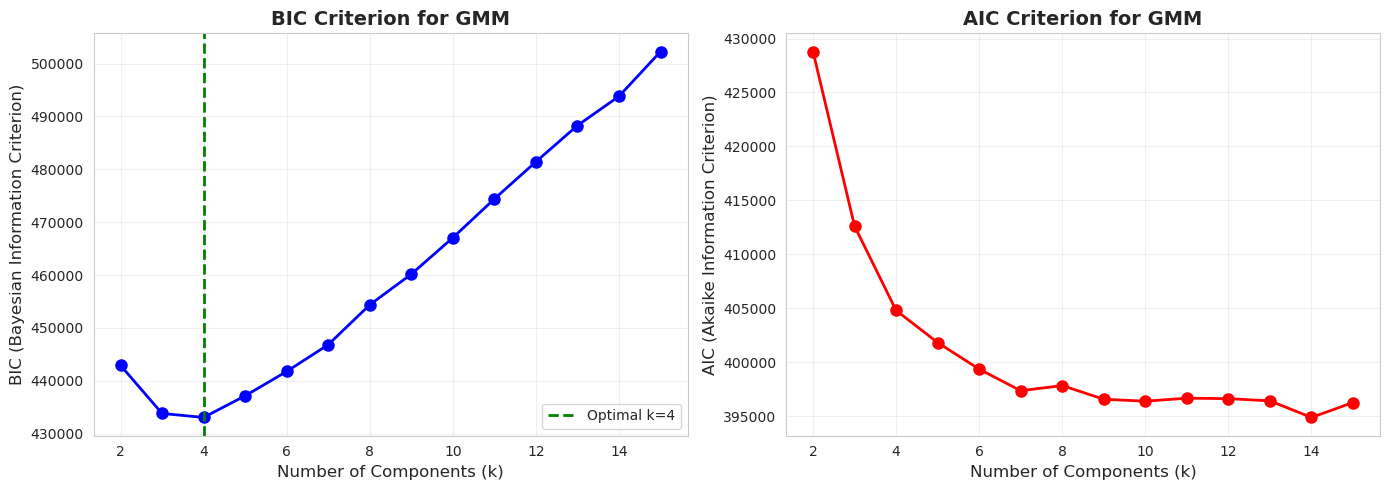


✓ Optimal k (lowest BIC): 4
✓ Optimal k (lowest AIC): 14

Using BIC optimal k=4 for final GMM model


In [23]:
# 1. BIC/AIC for model selection
print("=== Finding Optimal K for GMM ===\n")

bics = []
aics = []
K_range = range(2, 16)

print("Testing k values from 2 to 15...")
for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    gmm.fit(X_pca_reduced)
    bics.append(gmm.bic(X_pca_reduced))
    aics.append(gmm.aic(X_pca_reduced))
    if k % 3 == 0:
        print(f"  k={k}: BIC={bics[-1]:.2f}, AIC={aics[-1]:.2f}")

# Plot BIC and AIC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, bics, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Components (k)', fontsize=12)
ax1.set_ylabel('BIC (Bayesian Information Criterion)', fontsize=12)
ax1.set_title('BIC Criterion for GMM', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, aics, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Components (k)', fontsize=12)
ax2.set_ylabel('AIC (Akaike Information Criterion)', fontsize=12)
ax2.set_title('AIC Criterion for GMM', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Mark optimal k
optimal_k_gmm_bic = K_range[np.argmin(bics)]
optimal_k_gmm_aic = K_range[np.argmin(aics)]
ax1.axvline(optimal_k_gmm_bic, color='g', linestyle='--', linewidth=2, label=f'Optimal k={optimal_k_gmm_bic}')
ax1.legend()

plt.tight_layout()
plt.show()

print(f"\n✓ Optimal k (lowest BIC): {optimal_k_gmm_bic}")
print(f"✓ Optimal k (lowest AIC): {optimal_k_gmm_aic}")
print(f"\nUsing BIC optimal k={optimal_k_gmm_bic} for final GMM model")

=== Training Final GMM Model ===

✓ GMM clustering complete with k=4

Cluster sizes:
gmm_cluster
0     591
1    1726
2     967
3     604
Name: count, dtype: int64
✓ GMM clustering complete with k=4

Cluster sizes:
gmm_cluster
0     591
1    1726
2     967
3     604
Name: count, dtype: int64


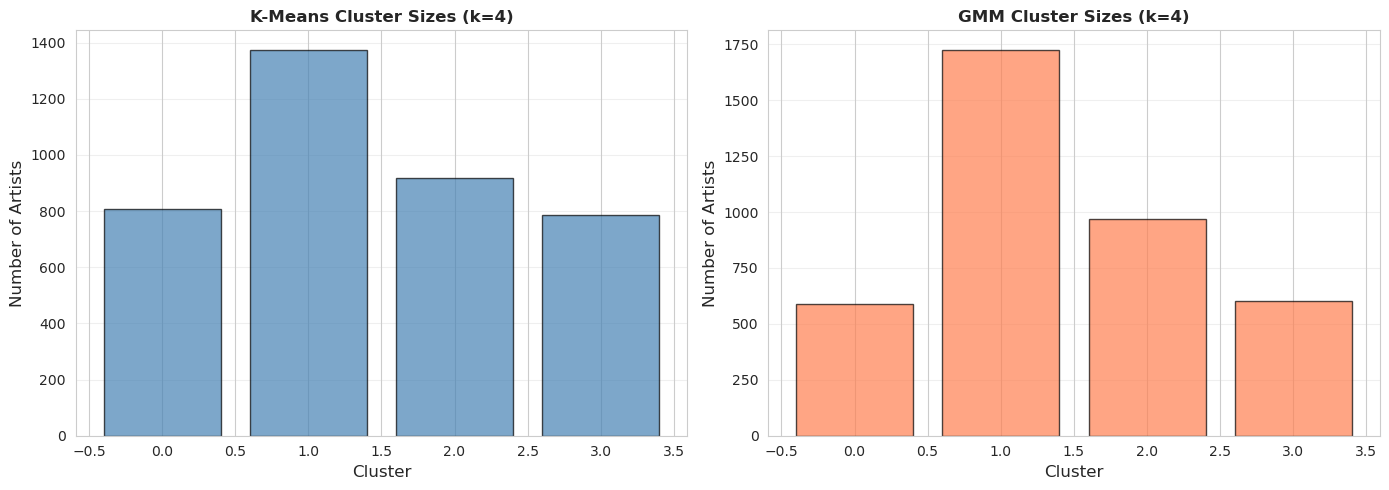

In [24]:
# 2. Train final GMM model
print("=== Training Final GMM Model ===\n")

gmm_final = GaussianMixture(n_components=optimal_k_gmm_bic, random_state=42, n_init=10)
artists_clean['gmm_cluster'] = gmm_final.fit_predict(X_pca_reduced)

print(f"✓ GMM clustering complete with k={optimal_k_gmm_bic}")
print(f"\nCluster sizes:")
print(artists_clean['gmm_cluster'].value_counts().sort_index())

# Compare GMM and K-Means cluster sizes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cluster_counts_kmeans = artists_clean['kmeans_cluster'].value_counts().sort_index()
ax1.bar(cluster_counts_kmeans.index, cluster_counts_kmeans.values, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Cluster', fontsize=12)
ax1.set_ylabel('Number of Artists', fontsize=12)
ax1.set_title(f'K-Means Cluster Sizes (k={optimal_k})', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

cluster_counts_gmm = artists_clean['gmm_cluster'].value_counts().sort_index()
ax2.bar(cluster_counts_gmm.index, cluster_counts_gmm.values, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Cluster', fontsize=12)
ax2.set_ylabel('Number of Artists', fontsize=12)
ax2.set_title(f'GMM Cluster Sizes (k={optimal_k_gmm_bic})', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Section 6A: K-Means Cluster Analysis & Interpretation

Understand what each K-Means cluster represents based on audio features and popularity metrics.

=== K-Means Cluster Profiles ===


=== Cluster 0 (n=809 artists) ===
artist_tempo_mean            130.389687
artist_loudness_mean          -7.958617
artist_duration_mean         226.816428
artist_timbre_mean_1_mean     46.517252
artist_pitch_mean_1_mean       0.461034

=== Cluster 1 (n=1375 artists) ===
artist_tempo_mean            126.455022
artist_loudness_mean          -8.301987
artist_duration_mean         242.464526
artist_timbre_mean_1_mean     45.117104
artist_pitch_mean_1_mean       0.464575

=== Cluster 2 (n=919 artists) ===
artist_tempo_mean            116.446727
artist_loudness_mean         -13.789968
artist_duration_mean         235.138424
artist_timbre_mean_1_mean     38.246207
artist_pitch_mean_1_mean       0.398557

=== Cluster 3 (n=785 artists) ===
artist_tempo_mean            118.961931
artist_loudness_mean         -11.922611
artist_duration_mean         272.108628
artist_timbre_mean_1_mean     39.593714
artist_pitch_mean_1_mean       0.443411


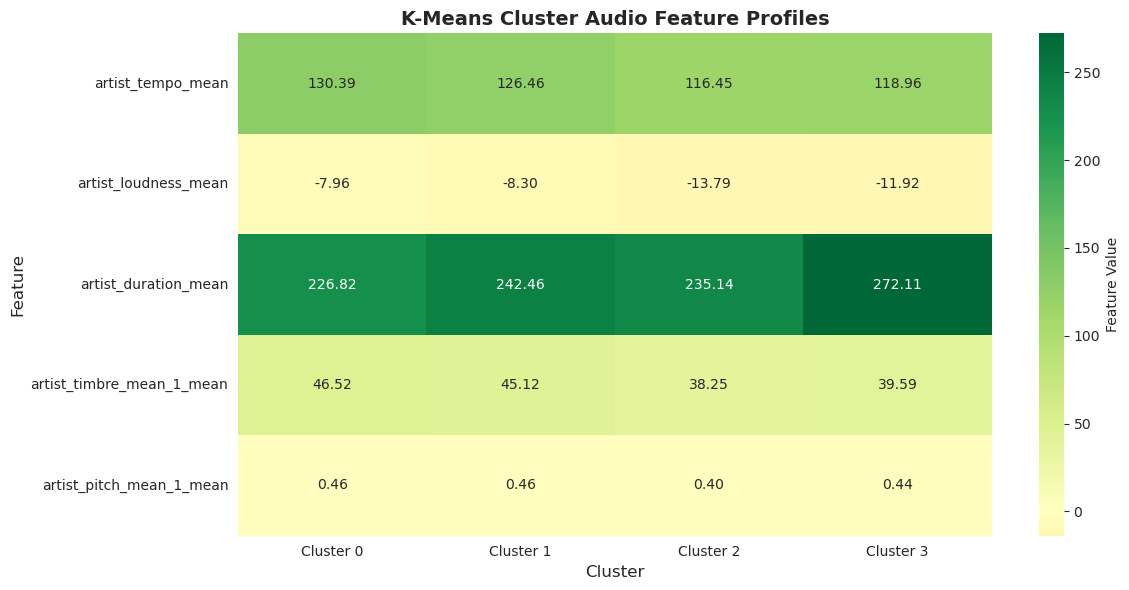

In [25]:
# 1. Cluster profiles (K-Means)
print("=== K-Means Cluster Profiles ===\n")

profile_features = ['artist_tempo_mean', 'artist_loudness_mean', 'artist_duration_mean',
                   'artist_timbre_mean_1_mean', 'artist_pitch_mean_1_mean']
profile_features = [f for f in profile_features if f in artists_clean.columns]

for cluster in sorted(artists_clean['kmeans_cluster'].unique()):
    cluster_data = artists_clean[artists_clean['kmeans_cluster'] == cluster]
    print(f"\n=== Cluster {cluster} (n={len(cluster_data)} artists) ===")
    print(cluster_data[profile_features].mean().to_string())

# Create a heatmap of cluster profiles
cluster_profiles = []
for cluster in sorted(artists_clean['kmeans_cluster'].unique()):
    cluster_data = artists_clean[artists_clean['kmeans_cluster'] == cluster]
    cluster_profiles.append(cluster_data[profile_features].mean())

cluster_profiles_df = pd.DataFrame(cluster_profiles,
                                   index=[f'Cluster {i}' for i in sorted(artists_clean['kmeans_cluster'].unique())])

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profiles_df.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Feature Value'})
plt.title('K-Means Cluster Audio Feature Profiles', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

=== Popularity Distribution by Cluster ===

Cluster 0:
  Mean Familiarity: 0.494
  Mean Hotttnesss: 0.319
Cluster 1:
  Mean Familiarity: 0.578
  Mean Hotttnesss: 0.390
Cluster 2:
  Mean Familiarity: 0.550
  Mean Hotttnesss: 0.375
Cluster 3:
  Mean Familiarity: 0.459
  Mean Hotttnesss: 0.296


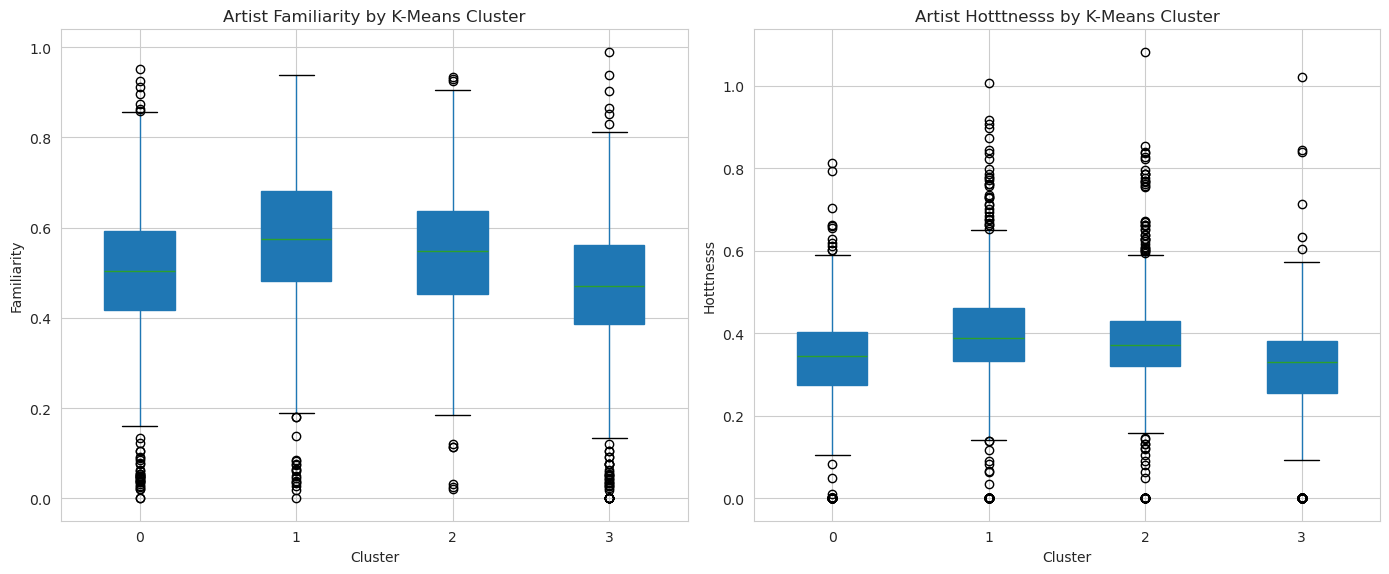

In [26]:
# 2. Popularity by cluster
print("=== Popularity Distribution by Cluster ===\n")

# Merge popularity data back
artists_analysis = artists_clean.copy()
if 'artist_familiarity_mean' not in artists_analysis.columns:
    artists_analysis = artists_analysis.merge(
        artists_df[['artist_id', 'artist_familiarity_mean', 'artist_hotttnesss_mean']],
        on='artist_id', how='left'
    )

for cluster in sorted(artists_analysis['kmeans_cluster'].unique()):
    cluster_data = artists_analysis[artists_analysis['kmeans_cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(f"  Mean Familiarity: {cluster_data['artist_familiarity_mean'].mean():.3f}")
    print(f"  Mean Hotttnesss: {cluster_data['artist_hotttnesss_mean'].mean():.3f}")

# Boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

artists_analysis.boxplot(column='artist_familiarity_mean', by='kmeans_cluster', ax=ax1, patch_artist=True)
ax1.set_title('Artist Familiarity by K-Means Cluster')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Familiarity')
ax1.get_figure().suptitle('')  # Remove default title

artists_analysis.boxplot(column='artist_hotttnesss_mean', by='kmeans_cluster', ax=ax2, patch_artist=True)
ax2.set_title('Artist Hotttnesss by K-Means Cluster')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Hotttnesss')
ax2.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

## Section 6B: GMM Cluster Analysis & Interpretation

Understand what each GMM cluster represents based on audio features and popularity metrics.

=== GMM Cluster Profiles ===


=== Cluster 0 (n=591 artists) ===
artist_tempo_mean            122.336589
artist_loudness_mean         -11.851262
artist_duration_mean         278.975146
artist_timbre_mean_1_mean     40.521693
artist_pitch_mean_1_mean       0.444387

=== Cluster 1 (n=1726 artists) ===
artist_tempo_mean            123.862635
artist_loudness_mean          -9.271088
artist_duration_mean         231.467720
artist_timbre_mean_1_mean     43.813808
artist_pitch_mean_1_mean       0.444227

=== Cluster 2 (n=967 artists) ===
artist_tempo_mean            126.573271
artist_loudness_mean          -8.728132
artist_duration_mean         231.723849
artist_timbre_mean_1_mean     44.671022
artist_pitch_mean_1_mean       0.455465

=== Cluster 3 (n=604 artists) ===
artist_tempo_mean            118.007258
artist_loudness_mean         -13.973320
artist_duration_mean         261.781689
artist_timbre_mean_1_mean     38.294657
artist_pitch_mean_1_mean       0.424362


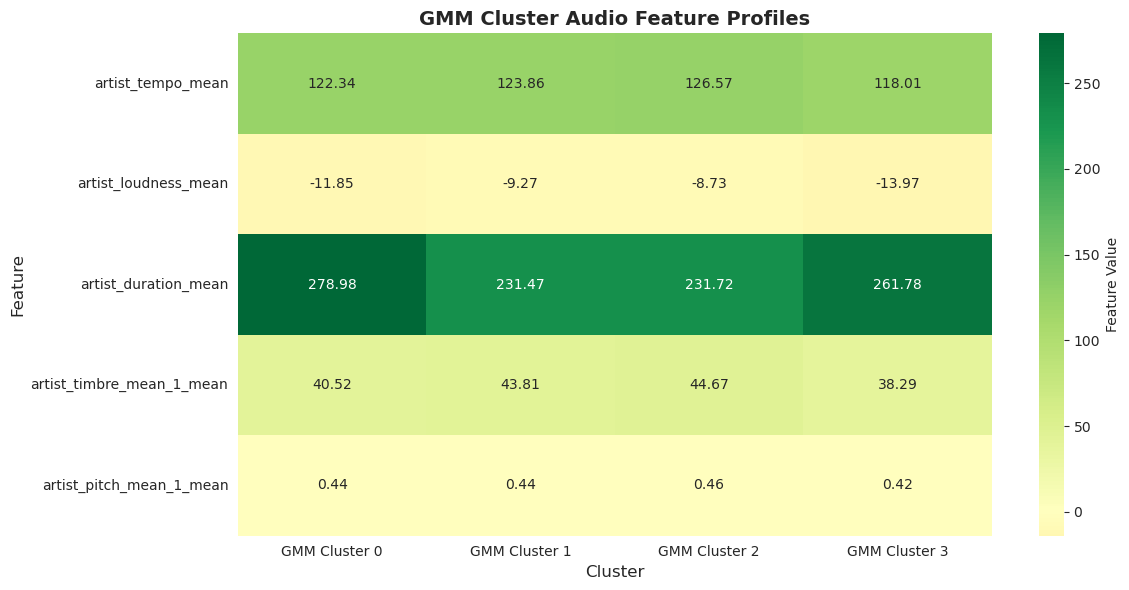

In [27]:
# 1. GMM Cluster profiles
print("=== GMM Cluster Profiles ===\n")

profile_features = ['artist_tempo_mean', 'artist_loudness_mean', 'artist_duration_mean',
                   'artist_timbre_mean_1_mean', 'artist_pitch_mean_1_mean']
profile_features = [f for f in profile_features if f in artists_clean.columns]

for cluster in sorted(artists_clean['gmm_cluster'].unique()):
    cluster_data = artists_clean[artists_clean['gmm_cluster'] == cluster]
    print(f"\n=== Cluster {cluster} (n={len(cluster_data)} artists) ===")
    print(cluster_data[profile_features].mean().to_string())

# Create a heatmap of GMM cluster profiles
gmm_cluster_profiles = []
for cluster in sorted(artists_clean['gmm_cluster'].unique()):
    cluster_data = artists_clean[artists_clean['gmm_cluster'] == cluster]
    gmm_cluster_profiles.append(cluster_data[profile_features].mean())

gmm_cluster_profiles_df = pd.DataFrame(gmm_cluster_profiles,
                                       index=[f'GMM Cluster {i}' for i in sorted(artists_clean['gmm_cluster'].unique())])

plt.figure(figsize=(12, 6))
sns.heatmap(gmm_cluster_profiles_df.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Feature Value'})
plt.title('GMM Cluster Audio Feature Profiles', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

=== GMM Popularity Distribution by Cluster ===

GMM Cluster 0:
  Mean Familiarity: 0.463
  Mean Hotttnesss: 0.296
GMM Cluster 1:
  Mean Familiarity: 0.582
  Mean Hotttnesss: 0.399
GMM Cluster 2:
  Mean Familiarity: 0.484
  Mean Hotttnesss: 0.313
GMM Cluster 3:
  Mean Familiarity: 0.518
  Mean Hotttnesss: 0.341


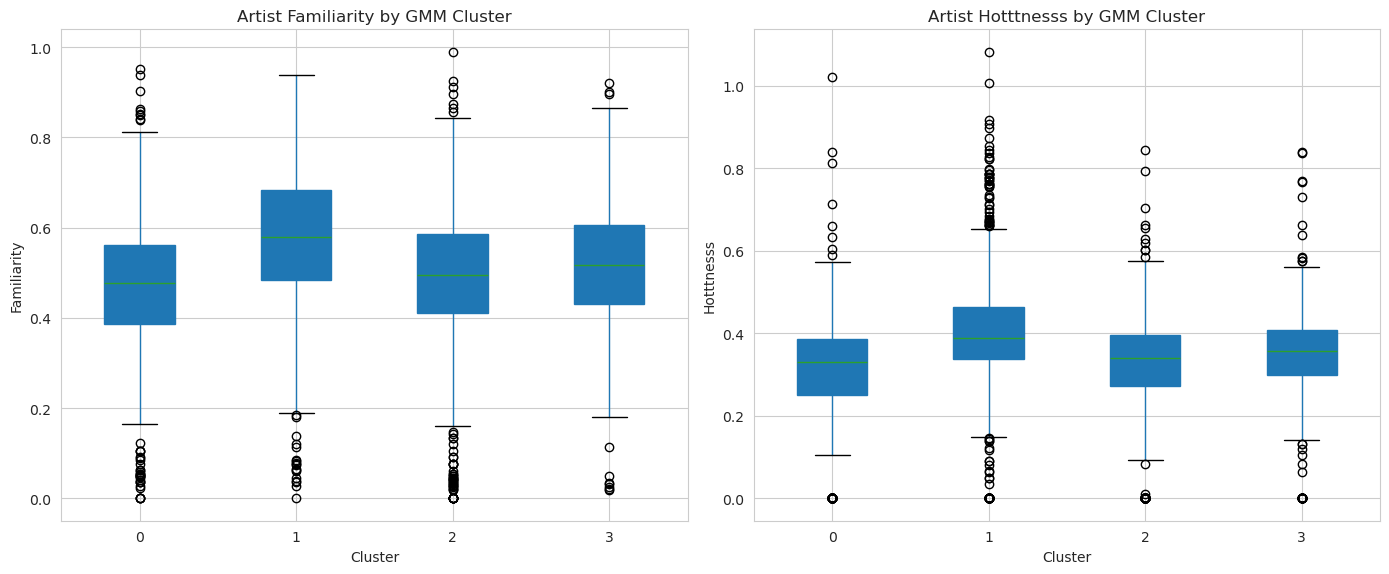

In [28]:
# 2. Popularity by GMM cluster
print("=== GMM Popularity Distribution by Cluster ===\n")

for cluster in sorted(artists_analysis['gmm_cluster'].unique()):
    cluster_data = artists_analysis[artists_analysis['gmm_cluster'] == cluster]
    print(f"GMM Cluster {cluster}:")
    print(f"  Mean Familiarity: {cluster_data['artist_familiarity_mean'].mean():.3f}")
    print(f"  Mean Hotttnesss: {cluster_data['artist_hotttnesss_mean'].mean():.3f}")

# Boxplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

artists_analysis.boxplot(column='artist_familiarity_mean', by='gmm_cluster', ax=ax1, patch_artist=True)
ax1.set_title('Artist Familiarity by GMM Cluster')
ax1.set_xlabel('Cluster')
ax1.set_ylabel('Familiarity')
ax1.get_figure().suptitle('')  # Remove default title

artists_analysis.boxplot(column='artist_hotttnesss_mean', by='gmm_cluster', ax=ax2, patch_artist=True)
ax2.set_title('Artist Hotttnesss by GMM Cluster')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Hotttnesss')
ax2.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

## Section 7A: Statistical Hypothesis Testing - K-Means

Formally test whether audio features and popularity differ significantly across K-Means clusters.

In [29]:
# 1. ANOVA - Cluster differences in key features
print("=== ANOVA: Feature Differences Across Clusters ===\n")

test_features = ['artist_tempo_mean', 'artist_loudness_mean', 'artist_duration_mean',
                'artist_timbre_mean_1_mean', 'artist_pitch_mean_1_mean']
test_features = [f for f in test_features if f in artists_analysis.columns]

anova_results = []
for feature in test_features:
    groups = [artists_analysis[artists_analysis['kmeans_cluster'] == c][feature].dropna()
              for c in sorted(artists_analysis['kmeans_cluster'].unique())]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append({
        'Feature': feature,
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
print(anova_df.to_string(index=False))
print(f"\n✓ {anova_df['Significant'].value_counts().get('Yes', 0)}/{len(anova_df)} features show significant differences (p < 0.05)")

=== ANOVA: Feature Differences Across Clusters ===

                  Feature  F-Statistic       p-value Significant
artist_timbre_mean_1_mean   698.043088  0.000000e+00         Yes
     artist_loudness_mean   439.677840 6.439858e-246         Yes
 artist_pitch_mean_1_mean    58.497069  5.564146e-37         Yes
        artist_tempo_mean    48.587840  8.056308e-31         Yes
     artist_duration_mean    32.001080  1.990458e-20         Yes

✓ 5/5 features show significant differences (p < 0.05)


In [30]:
# 2. ANOVA - Popularity by cluster
print("\n=== ANOVA: Popularity Differences Across Clusters ===\n")

for popularity_metric in ['artist_familiarity_mean', 'artist_hotttnesss_mean']:
    groups = [artists_analysis[artists_analysis['kmeans_cluster'] == c][popularity_metric].dropna()
              for c in sorted(artists_analysis['kmeans_cluster'].unique())]
    f_stat, p_value = f_oneway(*groups)
    print(f"{popularity_metric}:")
    print(f"  F-Statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.2e}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")
    if p_value < 0.05:
        print(f"  → Popularity differs significantly across clusters!")
    print()


=== ANOVA: Popularity Differences Across Clusters ===

artist_familiarity_mean:
  F-Statistic: 121.0174
  p-value: 6.28e-75
  Significant: Yes
  → Popularity differs significantly across clusters!

artist_hotttnesss_mean:
  F-Statistic: 100.8989
  p-value: 6.81e-63
  Significant: Yes
  → Popularity differs significantly across clusters!



In [31]:
# 3. t-tests - Popular vs Niche artists
print("=== t-tests: Popular vs Niche Artists ===\n")

familiarity_75 = artists_analysis['artist_familiarity_mean'].quantile(0.75)
familiarity_25 = artists_analysis['artist_familiarity_mean'].quantile(0.25)

popular = artists_analysis[artists_analysis['artist_familiarity_mean'] >= familiarity_75]
niche = artists_analysis[artists_analysis['artist_familiarity_mean'] <= familiarity_25]

print(f"Popular artists (top 25%, familiarity ≥ {familiarity_75:.3f}): n={len(popular)}")
print(f"Niche artists (bottom 25%, familiarity ≤ {familiarity_25:.3f}): n={len(niche)}\n")

ttest_results = []
for feature in test_features:
    pop_values = popular[feature].dropna()
    niche_values = niche[feature].dropna()

    if len(pop_values) > 1 and len(niche_values) > 1:
        t_stat, p_value = ttest_ind(pop_values, niche_values)

        # Calculate Cohen's d effect size
        pooled_std = np.sqrt((pop_values.std()**2 + niche_values.std()**2) / 2)
        cohens_d = (pop_values.mean() - niche_values.mean()) / pooled_std if pooled_std > 0 else 0

        ttest_results.append({
            'Feature': feature,
            't-Statistic': t_stat,
            'p-value': p_value,
            "Cohen's d": cohens_d,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })

ttest_df = pd.DataFrame(ttest_results).sort_values('t-Statistic', key=abs, ascending=False)
print(ttest_df.to_string(index=False))
print(f"\n✓ {ttest_df['Significant'].value_counts().get('Yes', 0)}/{len(ttest_df)} features show significant differences (p < 0.05)")
print(f"\nEffect sizes interpretation:")
print(f"  |Cohen's d| < 0.2: Small effect")
print(f"  |Cohen's d| 0.2-0.5: Medium effect")
print(f"  |Cohen's d| > 0.5: Large effect")

=== t-tests: Popular vs Niche Artists ===

Popular artists (top 25%, familiarity ≥ 0.625): n=972
Niche artists (bottom 25%, familiarity ≤ 0.438): n=972

                  Feature  t-Statistic      p-value  Cohen's d Significant
     artist_loudness_mean    15.706640 1.992827e-52   0.712468         Yes
artist_timbre_mean_1_mean    14.839800 2.845183e-47   0.673147         Yes
 artist_pitch_mean_1_mean     5.618788 2.200734e-08   0.254873         Yes
        artist_tempo_mean     2.625747 8.713803e-03   0.119106         Yes
     artist_duration_mean    -0.292070 7.702643e-01  -0.013249          No

✓ 4/5 features show significant differences (p < 0.05)

Effect sizes interpretation:
  |Cohen's d| < 0.2: Small effect
  |Cohen's d| 0.2-0.5: Medium effect
  |Cohen's d| > 0.5: Large effect


## Section 7B: Statistical Hypothesis Testing - GMM

Formally test whether audio features and popularity differ significantly across GMM clusters.

In [32]:
# 1. ANOVA - GMM Cluster differences in key features
print("=== ANOVA: Feature Differences Across GMM Clusters ===\n")

test_features = ['artist_tempo_mean', 'artist_loudness_mean', 'artist_duration_mean',
                'artist_timbre_mean_1_mean', 'artist_pitch_mean_1_mean']
test_features = [f for f in test_features if f in artists_analysis.columns]

anova_results_gmm = []
for feature in test_features:
    groups = [artists_analysis[artists_analysis['gmm_cluster'] == c][feature].dropna()
              for c in sorted(artists_analysis['gmm_cluster'].unique())]
    f_stat, p_value = f_oneway(*groups)
    anova_results_gmm.append({
        'Feature': feature,
        'F-Statistic': f_stat,
        'p-value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_gmm_df = pd.DataFrame(anova_results_gmm).sort_values('F-Statistic', ascending=False)
print(anova_gmm_df.to_string(index=False))
print(f"\n✓ {anova_gmm_df['Significant'].value_counts().get('Yes', 0)}/{len(anova_gmm_df)} features show significant differences (p < 0.05)")

=== ANOVA: Feature Differences Across GMM Clusters ===

                  Feature  F-Statistic       p-value Significant
artist_timbre_mean_1_mean   240.743123 2.871431e-143         Yes
     artist_loudness_mean   229.807030 3.007943e-137         Yes
     artist_duration_mean    46.069093  3.006729e-29         Yes
        artist_tempo_mean    11.932378  8.932319e-08         Yes
 artist_pitch_mean_1_mean     7.468633  5.530628e-05         Yes

✓ 5/5 features show significant differences (p < 0.05)


In [33]:
# 2. ANOVA - Popularity by GMM cluster
print("\n=== ANOVA: Popularity Differences Across GMM Clusters ===\n")

for popularity_metric in ['artist_familiarity_mean', 'artist_hotttnesss_mean']:
    groups = [artists_analysis[artists_analysis['gmm_cluster'] == c][popularity_metric].dropna()
              for c in sorted(artists_analysis['gmm_cluster'].unique())]
    f_stat, p_value = f_oneway(*groups)
    print(f"{popularity_metric}:")
    print(f"  F-Statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.2e}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")
    if p_value < 0.05:
        print(f"  → Popularity differs significantly across GMM clusters!")
    print()


=== ANOVA: Popularity Differences Across GMM Clusters ===

artist_familiarity_mean:
  F-Statistic: 135.1090
  p-value: 2.92e-83
  Significant: Yes
  → Popularity differs significantly across GMM clusters!

artist_hotttnesss_mean:
  F-Statistic: 124.8633
  p-value: 3.28e-77
  Significant: Yes
  → Popularity differs significantly across GMM clusters!



## Summary & Conclusions

Final summary of the clustering analysis and key findings.

In [34]:
# Save results
print("=== Saving Results ===\n")

# Save artists with both cluster assignments
artists_analysis.to_csv('output/artists_with_clusters.csv', index=False)
print("✓ Saved: output/artists_with_clusters.csv")

# Print comprehensive summary
print(f"\n{'='*70}")
print(f"{'CLUSTERING ANALYSIS SUMMARY':^70}")
print(f"{'='*70}")

print(f"\n{'DATA OVERVIEW':-^70}")
print(f"  Total artists analyzed: {len(artists_analysis)}")
print(f"  Features used for clustering: {len(clustering_features)}")
print(f"  PCA components: {n_components_85} (85% variance)")

print(f"\n{'K-MEANS RESULTS':-^70}")
print(f"  Tested k values: {test_k_values}")
print(f"  Optimal k: {optimal_k} (highest Silhouette score)")
print(f"  Silhouette score: {k_results_df.loc[best_k_idx, 'Silhouette']:.3f}")
print(f"  Davies-Bouldin Index: {k_results_df.loc[best_k_idx, 'Davies-Bouldin']:.3f}")
print(f"\n  Cluster sizes (K-Means):")
for cluster in sorted(artists_analysis['kmeans_cluster'].unique()):
    count = (artists_analysis['kmeans_cluster'] == cluster).sum()
    print(f"    Cluster {cluster}: {count} artists ({100*count/len(artists_analysis):.1f}%)")

print(f"\n{'GMM RESULTS':-^70}")
print(f"  Optimal k (BIC): {optimal_k_gmm_bic}")
print(f"  Optimal k (AIC): {optimal_k_gmm_aic}")
print(f"\n  Cluster sizes (GMM):")
for cluster in sorted(artists_analysis['gmm_cluster'].unique()):
    count = (artists_analysis['gmm_cluster'] == cluster).sum()
    print(f"    Cluster {cluster}: {count} artists ({100*count/len(artists_analysis):.1f}%)")

print(f"\n{'STATISTICAL TESTING - K-MEANS':-^70}")
print(f"  Features with significant cluster differences: {anova_df['Significant'].value_counts().get('Yes', 0)}/{len(anova_df)}")
print(f"  Features with popular vs niche differences: {ttest_df['Significant'].value_counts().get('Yes', 0)}/{len(ttest_df)}")

print(f"\n{'STATISTICAL TESTING - GMM':-^70}")
print(f"  Features with significant cluster differences: {anova_gmm_df['Significant'].value_counts().get('Yes', 0)}/{len(anova_gmm_df)}")

print(f"\n{'='*70}")
print(f"{'✓ ANALYSIS COMPLETE':^70}")
print(f"{'='*70}\n")

=== Saving Results ===

✓ Saved: output/artists_with_clusters.csv

                     CLUSTERING ANALYSIS SUMMARY                      

----------------------------DATA OVERVIEW-----------------------------
  Total artists analyzed: 3888
  Features used for clustering: 140
  PCA components: 46 (85% variance)

---------------------------K-MEANS RESULTS----------------------------
  Tested k values: [4, 5, 6, 7]
  Optimal k: 4 (highest Silhouette score)
  Silhouette score: 0.093
  Davies-Bouldin Index: 2.982

  Cluster sizes (K-Means):
    Cluster 0: 809 artists (20.8%)
    Cluster 1: 1375 artists (35.4%)
    Cluster 2: 919 artists (23.6%)
    Cluster 3: 785 artists (20.2%)

-----------------------------GMM RESULTS------------------------------
  Optimal k (BIC): 4
  Optimal k (AIC): 14

  Cluster sizes (GMM):
    Cluster 0: 591 artists (15.2%)
    Cluster 1: 1726 artists (44.4%)
    Cluster 2: 967 artists (24.9%)
    Cluster 3: 604 artists (15.5%)

--------------------STATISTICAL TES